# Análisis Bancario España (2007–2025)

**TFM · Análisis del sector bancario español mediante datos de mercado, macroeconómicos y financieros**

---

## 📋 Tabla de contenidos

1. [Configuración del entorno](#1-configuracion)
   - 1.1 Instalación de librerías
   - 1.2 Importación de librerías
   - 1.3 Definición de entidades bancarias
2. [Adquisición de datos](#2-adquisicion)
   - 2.1 Datos de mercado (Yahoo Finance)
   - 2.2 Indicadores macroeconómicos (World Bank)
   - 2.3 Tipos de interés BCE (FRED)
   - 2.4 Datos financieros fundamentales
3. [Integración y limpieza de datos](#3-integracion)
   - 3.1 Verificación y exportación parcial
   - 3.2 Unión de los datasets
   - 3.3 Validación del dataset maestro
4. [Ingeniería de variables: KPIs](#4-kpis)
5. [Análisis exploratorio y visualización](#5-analisis)
   - 5.1 Análisis exploratorio y evolutivo
   - 5.2 Análisis de sensibilidad macroeconómica

---


---
## 1. Configuración del entorno <a id='1-configuracion'></a>


### 1.1 Instalación de librerías

In [1]:
# instalar librerías
!pip install yfinance requests pandas openpyxl

### 1.2 Importación de librerías

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import requests
import yfinance as yf

### 1.3 Definición de entidades bancarias

Se analizan los 5 principales bancos cotizados en el mercado español (Bolsa de Madrid, sufijo `.MC`).

In [3]:
# Definir los bancos y tickers

bancos = {
    "Banco Santander": "SAN.MC",
    "BBVA": "BBVA.MC",
    "CaixaBank": "CABK.MC",
    "Banco Sabadell": "SAB.MC",
    "Bankinter": "BKT.MC"
}

---
## 2. Adquisición de datos <a id='2-adquisicion'></a>


### 2.1 Datos de mercado · Yahoo Finance

Se descarga el histórico de precios de cada banco desde `yfinance` con granularidad diaria (2007–2025) y se agrega a nivel anual, calculando precio medio, precio de cierre, rentabilidad y volatilidad.

In [4]:
# Descargar precios de mercado

start_date = "2007-01-01"
end_date = "2025-12-31"

market_data = []

for banco, ticker in bancos.items():
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)

    if df.empty:
        print(f"No se pudieron descargar datos para {banco} ({ticker})")
        continue

    # Aplana el MultiIndex de columnas
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()
    df["banco"] = banco
    df["ticker"] = ticker
    df["año"] = df["Date"].dt.year

    df["daily_return"] = df["Close"].pct_change() # (valor_hoy - valor_ayer) / valor_ayer

    annual = df.groupby(["banco", "ticker", "año"]).agg(  # agrupamos poer banco y año
        precio_accion_medio_anual=("Close", "mean"),  # promedio de los ~250 cierres (en finanzas se mide en días de mercado, no días naturales)
        precio_accion_cierre_anual=("Close", "last"),  # último cierre del año
        precio_accion_primer_dia_negociacion=("Close", "first"), # primer cierre del año
        volatilidad_anual=("daily_return", lambda x: x.std() * np.sqrt(252))
    ).reset_index()

    annual["rentabilidad_anual_accion"] = (
        annual["precio_accion_cierre_anual"] - annual["precio_accion_primer_dia_negociacion"]
    ) / annual["precio_accion_primer_dia_negociacion"]

    market_data.append(annual)

df_market = pd.concat(market_data, ignore_index=True)
df_market.head()

,banco,ticker,año,precio_accion_medio_anual,precio_accion_cierre_anual,precio_accion_primer_dia_negociacion,volatilidad_anual,rentabilidad_anual_accion
0,Banco Santander,SAN.MC,2007,4.277689,4.620027,4.244952,0.209655,0.088358
1,Banco Santander,SAN.MC,2008,3.600190,2.397039,4.557552,0.541298,-0.474051
2,Banco Santander,SAN.MC,2009,3.206195,4.421510,2.485819,0.461524,0.778693
3,Banco Santander,SAN.MC,2010,3.738985,3.228237,4.501900,0.453918,-0.282917
4,Banco Santander,SAN.MC,2011,3.119851,2.628698,3.244933,0.379841,-0.189907


### 2.2 Indicadores macroeconómicos · World Bank

Se consumen tres indicadores de la API pública del Banco Mundial para España (código `ESP`):
- **PIB** — crecimiento anual en % (`NY.GDP.MKTP.KD.ZG`)
- **Inflación** — precios al consumidor en % (`FP.CPI.TOTL.ZG`)
- **Desempleo** — % sobre la población activa (`SL.UEM.TOTL.ZS`)

Vamos a descargas los datos macroeconómicos de España desde el Banco Mundial (World Bank) y los vamos a unir en una sola tabla. Es el equivalente a lo que hicimos con Yahoo Finance, pero en lugar de precios de bolsa, son indicadores económicos del país.

In [5]:
def world_bank_indicator(country, indicator):
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator}?format=json&per_page=200"  #API publica gratuita
    response = requests.get(url)
    data = response.json()

    if len(data) < 2:
        return pd.DataFrame()

    records = data[1]
    df = pd.DataFrame(records)[["date", "value"]]
    df = df.rename(columns={"date": "año", "value": indicator})
    df["año"] = pd.to_numeric(df["año"], errors="coerce")
    return df

# Definimos años
año_min, año_max = 2007, 2025

# Indicadores
# PIB crecimiento (% anual)
df_gdp = world_bank_indicator("ESP", "NY.GDP.MKTP.KD.ZG")

# Inflación, precios al consumidor (% anual)
df_inflation = world_bank_indicator("ESP", "FP.CPI.TOTL.ZG")

# Desempleo total (% de la población activa total)
df_unemployment = world_bank_indicator("ESP", "SL.UEM.TOTL.ZS")

# Filtrar por rango de años
df_gdp          = df_gdp[df_gdp["año"].between(año_min, año_max)]
df_inflation    = df_inflation[df_inflation["año"].between(año_min, año_max)]
df_unemployment = df_unemployment[df_unemployment["año"].between(año_min, año_max)]

# Unir
df_macro = df_gdp.merge(df_inflation, on="año", how="outer")
df_macro = df_macro.merge(df_unemployment, on="año", how="outer")

# Renombrar
df_macro = df_macro.rename(columns={
    "NY.GDP.MKTP.KD.ZG": "PIB_crecimiento",
    "FP.CPI.TOTL.ZG": "inflacion",
    "SL.UEM.TOTL.ZS": "tasa_desempleo"
})

df_macro = df_macro.sort_values("año").reset_index(drop=True)
df_macro.head()

,año,PIB_crecimiento,inflacion,tasa_desempleo
0,2007,3.533500,2.786797,8.232
1,2008,0.767166,4.075343,11.254
2,2009,-3.768133,-0.287813,17.857
3,2010,0.094122,1.799865,19.860
4,2011,-0.639921,3.196102,21.390


In [6]:
df_macro.tail()

,año,PIB_crecimiento,inflacion,tasa_desempleo
14,2021,6.683144,3.093135,14.914
15,2022,6.370317,8.390576,13.033
16,2023,2.460858,3.532361,12.179
17,2024,3.455254,2.774178,11.400
18,2025,NaN,NaN,10.376


In [7]:
print(df_market.info())
print(df_macro.info())

print(df_market["año"].min(), df_market["año"].max())
print(df_macro["año"].min(), df_macro["año"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   banco                                 95 non-null     object 
 1   ticker                                95 non-null     object 
 2   año                                   95 non-null     int32  
 3   precio_accion_medio_anual             95 non-null     float64
 4   precio_accion_cierre_anual            95 non-null     float64
 5   precio_accion_primer_dia_negociacion  95 non-null     float64
 6   volatilidad_anual                     95 non-null     float64
 7   rentabilidad_anual_accion             95 non-null     float64
dtypes: float64(5), int32(1), object(2)
memory usage: 5.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------  

**Problema:** Tipos distintos en `año`.



```
df_market  → año es int32
df_macro   → año es int64
```

Pandas puede tener problemas al hacer el merge si los tipos no coinciden. Conviene homogeneizarlos antes:


In [8]:
df_market["año"] = df_market["año"].astype(int)
df_macro["año"]  = df_macro["año"].astype(int)

**Exportación:**

In [9]:
df_market.to_csv("datos_mercado_anuales.csv", index=False)
df_macro.to_csv("datos_macro_espana.csv", index=False)

print("Archivos guardados:")
print("- datos_mercado_anuales.csv")
print("- datos_macro_espana.csv")

Archivos guardados:
- datos_mercado_anuales.csv
- datos_macro_espana.csv


**Validaciones:**

In [10]:
print("\nAños mercado:", df_market["año"].min(), "-", df_market["año"].max())
print("Años macro:", df_macro["año"].min(), "-", df_macro["año"].max())

print("\nBancos en mercado:")
print(df_market["banco"].unique())

print("\nNulos mercado:")
print(df_market.isnull().sum())

print("\nNulos macro:")
print(df_macro.isnull().sum())


Años mercado: 2007 - 2025
Años macro: 2007 - 2025

Bancos en mercado:
['Banco Santander' 'BBVA' 'CaixaBank' 'Banco Sabadell' 'Bankinter']

Nulos mercado:
banco                                   0
ticker                                  0
año                                     0
precio_accion_medio_anual               0
precio_accion_cierre_anual              0
precio_accion_primer_dia_negociacion    0
volatilidad_anual                       0
rentabilidad_anual_accion               0
dtype: int64

Nulos macro:
año                0
PIB_crecimiento    1
inflacion          1
tasa_desempleo     0
dtype: int64


### 2.3 Tipos de interés BCE · FRED

Se añade el tipo de interés oficial del Banco Central Europeo (deposit facility rate, serie `ECBDFR`) vía la API de FRED, agregado como media anual.

In [11]:
!pip install fredapi

In [12]:
# Descargar tipo de interés

from fredapi import Fred

# Sustituye por tu API key
fred = Fred(api_key="API")

# Tipo de interés del BCE (deposit facility rate)
series = fred.get_series("ECBDFR")

df_rates = series.reset_index()
df_rates.columns = ["date", "tipo_interes"]

df_rates["año"] = df_rates["date"].dt.year

# Convertir a anual (media del año)
df_rates_anual = df_rates.groupby("año")["tipo_interes"].mean().reset_index()

df_rates_anual.head()

,año,tipo_interes
0,1999,1.749315
1,2000,3.018443
2,2001,3.288356
3,2002,2.214384
4,2003,1.258219


In [13]:
#definimos años
año_min,año_max=2007,2025

df_rates_anual = df_rates_anual[df_rates_anual["año"].between(año_min, año_max)]
df_rates_anual.head()

,año,tipo_interes
8,2007,2.839041
9,2008,3.005464
10,2009,0.465753
11,2010,0.250000
12,2011,0.499315


In [14]:
# Integramos con el dataset macro

df_macro = df_macro.merge(df_rates_anual, on="año", how="left")
df_macro.head()

,año,PIB_crecimiento,inflacion,tasa_desempleo,tipo_interes
0,2007,3.533500,2.786797,8.232,2.839041
1,2008,0.767166,4.075343,11.254,3.005464
2,2009,-3.768133,-0.287813,17.857,0.465753
3,2010,0.094122,1.799865,19.860,0.250000
4,2011,-0.639921,3.196102,21.390,0.499315


Se ha incorporado el tipo de interés oficial del Banco Central Europeo como variable clave para analizar su impacto en la rentabilidad bancaria, dado su efecto directo sobre los márgenes de intermediación

In [15]:
df_market

,banco,ticker,año,precio_accion_medio_anual,precio_accion_cierre_anual,precio_accion_primer_dia_negociacion,volatilidad_anual,rentabilidad_anual_accion
0,Banco Santander,SAN.MC,2007,4.277689,4.620027,4.244952,0.209655,0.088358
1,Banco Santander,SAN.MC,2008,3.600190,2.397039,4.557552,0.541298,-0.474051
2,Banco Santander,SAN.MC,2009,3.206195,4.421510,2.485819,0.461524,0.778693
3,Banco Santander,SAN.MC,2010,3.738985,3.228237,4.501900,0.453918,-0.282917
4,Banco Santander,SAN.MC,2011,3.119851,2.628698,3.244933,0.379841,-0.189907
...,...,...,...,...,...,...,...,...
90,Bankinter,BKT.MC,2021,3.303704,3.483831,2.298010,0.297415,0.516021
91,Bankinter,BKT.MC,2022,4.339768,5.081937,3.525554,0.375894,0.441458
92,Bankinter,BKT.MC,2023,4.982599,5.091766,5.180852,0.277212,-0.017195
93,Bankinter,BKT.MC,2024,6.519814,7.199386,5.242867,0.240441,0.373177


### 2.4 Datos financieros fundamentales

Se carga el dataset `bd_finanzas.xlsx` desde Google Drive, que contiene métricas de balance y cuenta de resultados de cada entidad (activo total, márgenes, beneficio neto, ratios de solvencia y morosidad) para el período 2007–2025.

In [16]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
df_finanzas = pd.read_excel("/content/drive/MyDrive/TFM/tfm_finance_dashboard/data/raw/bd_finanzas.xlsx")
#df_finanzas["fecha"] = pd.to_datetime(df_finanzas["fecha"])
#df_finanzas["año"] = df_finanzas["fecha"].dt.year

df_finanzas.head()

,empresa,ticker,año,activo_total,prestamos_clientela,depositos_clientela,patrimonio_neto,margen_intereses,margen_bruto,margen_neto,beneficio_neto,ratio_cet1,ratio_morosidad,coste_riesgo
0,Santander,SAN,2025,1867515,1037288,1041200,112748,42348,58670,33959,14101,13.50,2.91,1.15
1,Santander,SAN,2024,1837081,1054069,1055936,107327,46668,61876,35842,12574,12.80,3.05,1.15
2,Santander,SAN,2023,1797062,1036349,1047169,104241,43261,57423,31998,11076,12.30,3.14,1.18
3,Santander,SAN,2022,1734659,1036004,1025401,97585,38619,52117,28214,9605,12.04,3.08,0.99
4,Santander,SAN,2021,1595835,972682,918344,97053,33370,46404,24989,8124,12.12,3.16,0.77


---
## 3. Integración y limpieza de datos <a id='3-integracion'></a>


### 3.1 Verificación y exportación parcial

Se comprueba la coherencia de tipos, rango temporal y valores nulos antes de continuar. Se exporta `df_market` como CSV de respaldo.

In [18]:
print(df_finanzas.columns)
print(df_market.columns)
print(df_macro.columns)

Index(['empresa', 'ticker', 'año', 'activo_total', 'prestamos_clientela',
       'depositos_clientela', 'patrimonio_neto', 'margen_intereses',
       'margen_bruto', 'margen_neto', 'beneficio_neto', 'ratio_cet1',
       'ratio_morosidad', 'coste_riesgo'],
      dtype='object')
Index(['banco', 'ticker', 'año', 'precio_accion_medio_anual',
       'precio_accion_cierre_anual', 'precio_accion_primer_dia_negociacion',
       'volatilidad_anual', 'rentabilidad_anual_accion'],
      dtype='object')
Index(['año', 'PIB_crecimiento', 'inflacion', 'tasa_desempleo',
       'tipo_interes'],
      dtype='object')


In [19]:
df_finanzas

,empresa,ticker,año,activo_total,prestamos_clientela,depositos_clientela,patrimonio_neto,margen_intereses,margen_bruto,margen_neto,beneficio_neto,ratio_cet1,ratio_morosidad,coste_riesgo
0,Santander,SAN,2025,1867515,1037288,1041200,112748,42348,58670,33959,14101,13.50,2.91,1.15
1,Santander,SAN,2024,1837081,1054069,1055936,107327,46668,61876,35842,12574,12.80,3.05,1.15
2,Santander,SAN,2023,1797062,1036349,1047169,104241,43261,57423,31998,11076,12.30,3.14,1.18
3,Santander,SAN,2022,1734659,1036004,1025401,97585,38619,52117,28214,9605,12.04,3.08,0.99
4,Santander,SAN,2021,1595835,972682,918344,97053,33370,46404,24989,8124,12.12,3.16,0.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Bankinter,BKT,2011,59491,42605,38700,3100,677,1202,508,181,9.36,3.21,0.57
91,Bankinter,BKT,2010,54098,41700,36800,2950,597,1120,456,150,9.00,2.56,0.47
92,Bankinter,BKT,2009,54468,39884,35900,2850,793,1245,363,254,9.00,2.46,0.43
93,Bankinter,BKT,2008,53468,40144,37343,2700,681,1055,339,252,7.70,1.34,0.31


In [20]:
# Cambio nombre de los bancos. Si es banco santander, poner solo santander

df_market["banco"] = df_market["banco"].str.replace("Banco ", "", regex=False)
df_market

,banco,ticker,año,precio_accion_medio_anual,precio_accion_cierre_anual,precio_accion_primer_dia_negociacion,volatilidad_anual,rentabilidad_anual_accion
0,Santander,SAN.MC,2007,4.277689,4.620027,4.244952,0.209655,0.088358
1,Santander,SAN.MC,2008,3.600190,2.397039,4.557552,0.541298,-0.474051
2,Santander,SAN.MC,2009,3.206195,4.421510,2.485819,0.461524,0.778693
3,Santander,SAN.MC,2010,3.738985,3.228237,4.501900,0.453918,-0.282917
4,Santander,SAN.MC,2011,3.119851,2.628698,3.244933,0.379841,-0.189907
...,...,...,...,...,...,...,...,...
90,Bankinter,BKT.MC,2021,3.303704,3.483831,2.298010,0.297415,0.516021
91,Bankinter,BKT.MC,2022,4.339768,5.081937,3.525554,0.375894,0.441458
92,Bankinter,BKT.MC,2023,4.982599,5.091766,5.180852,0.277212,-0.017195
93,Bankinter,BKT.MC,2024,6.519814,7.199386,5.242867,0.240441,0.373177


In [21]:
# renombrar
df_finanzas.rename(columns={"empresa": "banco"}, inplace=True)
df_finanzas["banco"] = df_finanzas["banco"].str.replace("Banco ", "", regex=False)
df_finanzas

,banco,ticker,año,activo_total,prestamos_clientela,depositos_clientela,patrimonio_neto,margen_intereses,margen_bruto,margen_neto,beneficio_neto,ratio_cet1,ratio_morosidad,coste_riesgo
0,Santander,SAN,2025,1867515,1037288,1041200,112748,42348,58670,33959,14101,13.50,2.91,1.15
1,Santander,SAN,2024,1837081,1054069,1055936,107327,46668,61876,35842,12574,12.80,3.05,1.15
2,Santander,SAN,2023,1797062,1036349,1047169,104241,43261,57423,31998,11076,12.30,3.14,1.18
3,Santander,SAN,2022,1734659,1036004,1025401,97585,38619,52117,28214,9605,12.04,3.08,0.99
4,Santander,SAN,2021,1595835,972682,918344,97053,33370,46404,24989,8124,12.12,3.16,0.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Bankinter,BKT,2011,59491,42605,38700,3100,677,1202,508,181,9.36,3.21,0.57
91,Bankinter,BKT,2010,54098,41700,36800,2950,597,1120,456,150,9.00,2.56,0.47
92,Bankinter,BKT,2009,54468,39884,35900,2850,793,1245,363,254,9.00,2.46,0.43
93,Bankinter,BKT,2008,53468,40144,37343,2700,681,1055,339,252,7.70,1.34,0.31


In [22]:
df_macro

,año,PIB_crecimiento,inflacion,tasa_desempleo,tipo_interes
0,2007,3.533500,2.786797,8.232,2.839041
1,2008,0.767166,4.075343,11.254,3.005464
2,2009,-3.768133,-0.287813,17.857,0.465753
3,2010,0.094122,1.799865,19.860,0.250000
4,2011,-0.639921,3.196102,21.390,0.499315
5,2012,-2.865114,2.446128,24.789,0.131148
6,2013,-1.427322,1.408581,26.094,0.000000
7,2014,1.520486,-0.151115,24.441,-0.086849
8,2015,4.060867,-0.500366,22.057,-0.206301
9,2016,2.915156,-0.202598,19.635,-0.379508


In [23]:
print(df_finanzas["banco"].unique())
print(df_market["banco"].unique())


print(df_finanzas["ticker"].unique())
print(df_market["ticker"].unique())

['Santander' 'BBVA' 'CaixaBank' 'Sabadell' 'Bankinter']
['Santander' 'BBVA' 'CaixaBank' 'Sabadell' 'Bankinter']
['SAN' 'BBVA' 'CABK' 'SAB' 'BKT']
['SAN.MC' 'BBVA.MC' 'CABK.MC' 'SAB.MC' 'BKT.MC']


In [24]:
df_finanzas["ticker"] = df_finanzas["ticker"].astype(str) + ".MC"

### 3.2 Unión de los datasets

Se fusionan los cuatro datasets mediante `merge` sobre las claves `banco`, `ticker` y `año`, construyendo el **dataset maestro** (`df_master`) que concentra todas las dimensiones del análisis.

In [25]:
#unir datos financieros + mercado

df_master = pd.merge(
    df_finanzas,
    df_market,
    on=["banco", "ticker", "año"],
    how="left"
)

In [26]:
df_master

,banco,ticker,año,activo_total,prestamos_clientela,depositos_clientela,patrimonio_neto,margen_intereses,margen_bruto,margen_neto,beneficio_neto,ratio_cet1,ratio_morosidad,coste_riesgo,precio_accion_medio_anual,precio_accion_cierre_anual,precio_accion_primer_dia_negociacion,volatilidad_anual,rentabilidad_anual_accion
0,Santander,SAN.MC,2025,1867515,1037288,1041200,112748,42348,58670,33959,14101,13.50,2.91,1.15,7.121268,10.005154,4.222449,0.314054,1.369514
1,Santander,SAN.MC,2024,1837081,1054069,1055936,107327,46668,61876,35842,12574,12.80,3.05,1.15,4.072431,4.281427,3.542465,0.255114,0.208601
2,Santander,SAN.MC,2023,1797062,1036349,1047169,104241,43261,57423,31998,11076,12.30,3.14,1.18,3.093171,3.474438,2.513818,0.284570,0.382136
3,Santander,SAN.MC,2022,1734659,1036004,1025401,97585,38619,52117,28214,9605,12.04,3.08,0.99,2.404764,2.472354,2.499269,0.351434,-0.010769
4,Santander,SAN.MC,2021,1595835,972682,918344,97053,33370,46404,24989,8124,12.12,3.16,0.77,2.549549,2.490798,2.123436,0.305269,0.173003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Bankinter,BKT.MC,2011,59491,42605,38700,3100,677,1202,508,181,9.36,3.21,0.57,0.624632,0.686576,0.565712,0.774668,0.213648
91,Bankinter,BKT.MC,2010,54098,41700,36800,2950,597,1120,456,150,9.00,2.56,0.47,0.684998,0.556837,0.885471,0.426932,-0.371140
92,Bankinter,BKT.MC,2009,54468,39884,35900,2850,793,1245,363,254,9.00,2.46,0.43,0.885342,0.840631,0.661962,0.388208,0.269909
93,Bankinter,BKT.MC,2008,53468,40144,37343,2700,681,1055,339,252,7.70,1.34,0.31,0.822111,0.627491,1.161734,0.511293,-0.459867


In [27]:
# añadir datos macro

df_master = pd.merge(
    df_master,
    df_macro,
    on="año",
    how="left"
)
df_master

,banco,ticker,año,activo_total,prestamos_clientela,depositos_clientela,patrimonio_neto,margen_intereses,margen_bruto,margen_neto,...,coste_riesgo,precio_accion_medio_anual,precio_accion_cierre_anual,precio_accion_primer_dia_negociacion,volatilidad_anual,rentabilidad_anual_accion,PIB_crecimiento,inflacion,tasa_desempleo,tipo_interes
0,Santander,SAN.MC,2025,1867515,1037288,1041200,112748,42348,58670,33959,...,1.15,7.121268,10.005154,4.222449,0.314054,1.369514,NaN,NaN,10.376,2.258904
1,Santander,SAN.MC,2024,1837081,1054069,1055936,107327,46668,61876,35842,...,1.15,4.072431,4.281427,3.542465,0.255114,0.208601,3.455254,2.774178,11.400,3.732240
2,Santander,SAN.MC,2023,1797062,1036349,1047169,104241,43261,57423,31998,...,1.18,3.093171,3.474438,2.513818,0.284570,0.382136,2.460858,3.532361,12.179,3.307534
3,Santander,SAN.MC,2022,1734659,1036004,1025401,97585,38619,52117,28214,...,0.99,2.404764,2.472354,2.499269,0.351434,-0.010769,6.370317,8.390576,13.033,0.078767
4,Santander,SAN.MC,2021,1595835,972682,918344,97053,33370,46404,24989,...,0.77,2.549549,2.490798,2.123436,0.305269,0.173003,6.683144,3.093135,14.914,-0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Bankinter,BKT.MC,2011,59491,42605,38700,3100,677,1202,508,...,0.57,0.624632,0.686576,0.565712,0.774668,0.213648,-0.639921,3.196102,21.390,0.499315
91,Bankinter,BKT.MC,2010,54098,41700,36800,2950,597,1120,456,...,0.47,0.684998,0.556837,0.885471,0.426932,-0.371140,0.094122,1.799865,19.860,0.250000
92,Bankinter,BKT.MC,2009,54468,39884,35900,2850,793,1245,363,...,0.43,0.885342,0.840631,0.661962,0.388208,0.269909,-3.768133,-0.287813,17.857,0.465753
93,Bankinter,BKT.MC,2008,53468,40144,37343,2700,681,1055,339,...,0.31,0.822111,0.627491,1.161734,0.511293,-0.459867,0.767166,4.075343,11.254,3.005464


In [28]:
df_master.head()
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   banco                                 95 non-null     object 
 1   ticker                                95 non-null     object 
 2   año                                   95 non-null     int64  
 3   activo_total                          95 non-null     int64  
 4   prestamos_clientela                   95 non-null     int64  
 5   depositos_clientela                   95 non-null     int64  
 6   patrimonio_neto                       95 non-null     int64  
 7   margen_intereses                      95 non-null     int64  
 8   margen_bruto                          95 non-null     int64  
 9   margen_neto                           95 non-null     int64  
 10  beneficio_neto                        95 non-null     int64  
 11  ratio_cet1           

### 3.3 Validación del dataset maestro

Comprobaciones finales: ausencia de duplicados, cobertura temporal completa (2007–2025) y revisión de nulos.

In [29]:
# valores nulos

df_master.isnull().sum()

,0
banco,0
ticker,0
año,0
activo_total,0
prestamos_clientela,0
depositos_clientela,0
patrimonio_neto,0
margen_intereses,0
margen_bruto,0
margen_neto,0


In [30]:
# duplicados

df_master.duplicated(subset=["banco", "año"]).sum()

np.int64(0)

In [31]:
# Rango temporal
print(df_master["año"].min(), df_master["año"].max())

2007 2025


In [32]:
df_master.head()

,banco,ticker,año,activo_total,prestamos_clientela,depositos_clientela,patrimonio_neto,margen_intereses,margen_bruto,margen_neto,...,coste_riesgo,precio_accion_medio_anual,precio_accion_cierre_anual,precio_accion_primer_dia_negociacion,volatilidad_anual,rentabilidad_anual_accion,PIB_crecimiento,inflacion,tasa_desempleo,tipo_interes
0,Santander,SAN.MC,2025,1867515,1037288,1041200,112748,42348,58670,33959,...,1.15,7.121268,10.005154,4.222449,0.314054,1.369514,NaN,NaN,10.376,2.258904
1,Santander,SAN.MC,2024,1837081,1054069,1055936,107327,46668,61876,35842,...,1.15,4.072431,4.281427,3.542465,0.255114,0.208601,3.455254,2.774178,11.400,3.732240
2,Santander,SAN.MC,2023,1797062,1036349,1047169,104241,43261,57423,31998,...,1.18,3.093171,3.474438,2.513818,0.284570,0.382136,2.460858,3.532361,12.179,3.307534
3,Santander,SAN.MC,2022,1734659,1036004,1025401,97585,38619,52117,28214,...,0.99,2.404764,2.472354,2.499269,0.351434,-0.010769,6.370317,8.390576,13.033,0.078767
4,Santander,SAN.MC,2021,1595835,972682,918344,97053,33370,46404,24989,...,0.77,2.549549,2.490798,2.123436,0.305269,0.173003,6.683144,3.093135,14.914,-0.500000


**Resultado final:**

banco | ticker | año | variables_financieras | variables_mercado | variables_macro

---
## 4. Ingeniería de variables: KPIs <a id='4-kpis'></a>

Se calculan los indicadores clave de rendimiento bancario a partir de los datos brutos: rentabilidad sobre fondos propios (ROE), rentabilidad sobre activos (ROA), ratio préstamos/depósitos y otros ratios de eficiencia. El dataset resultante se exporta para su uso en el dashboard.

In [33]:
import pandas as pd
import numpy as np


# 1. CÁLCULO DE KPIs (formato ancho)

df_kpis = df_master[["banco", "ticker", "año"]].copy()

# ── Rentabilidad
df_kpis["ROE"] = df_master["beneficio_neto"] / df_master["patrimonio_neto"]

df_kpis["ROA"] = df_master["beneficio_neto"] / df_master["activo_total"]

df_kpis["margen_neto_sobre_activo"] = df_master["margen_neto"] / df_master["activo_total"]

df_kpis["rentabilidad_anual_accion"] = df_master["rentabilidad_anual_accion"]

# ── Eficiencia
# Ratio de eficiencia: aproximado como 1 - (margen_neto / margen_bruto)
# Cuanto más bajo, más eficiente
df_kpis["ratio_eficiencia"] = 1 - (df_master["margen_neto"] / df_master["margen_bruto"])

# Margen de intereses sobre activo total (NIM aproximado)
df_kpis["NIM"] = df_master["margen_intereses"] / df_master["activo_total"]

# ── Solvencia y riesgo
df_kpis["CET1"] = df_master["ratio_cet1"]

df_kpis["ratio_morosidad"] = df_master["ratio_morosidad"]

df_kpis["coste_riesgo"] = df_master["coste_riesgo"]

# Apalancamiento: activo total / patrimonio neto
df_kpis["apalancamiento"] = df_master["activo_total"] / df_master["patrimonio_neto"]

# Ratio créditos sobre depósitos (LTD: Loan-to-Deposit)
df_kpis["LTD"] = df_master["prestamos_clientela"] / df_master["depositos_clientela"]

# ── Valoración de mercado
df_kpis["volatilidad_anual"] = df_master["volatilidad_anual"]

df_kpis["precio_cierre"] = df_master["precio_accion_cierre_anual"]

print("Dataset de KPIs (formato ancho):")
print(df_kpis.shape)
df_kpis.head()

Dataset de KPIs (formato ancho):
(95, 16)


,banco,ticker,año,ROE,ROA,margen_neto_sobre_activo,rentabilidad_anual_accion,ratio_eficiencia,NIM,CET1,ratio_morosidad,coste_riesgo,apalancamiento,LTD,volatilidad_anual,precio_cierre
0,Santander,SAN.MC,2025,0.125067,0.007551,0.018184,1.369514,0.421186,0.022676,13.50,2.91,1.15,16.563620,0.996243,0.314054,10.005154
1,Santander,SAN.MC,2024,0.117156,0.006845,0.019510,0.208601,0.420745,0.025403,12.80,3.05,1.15,17.116671,0.998232,0.255114,4.281427
2,Santander,SAN.MC,2023,0.106254,0.006163,0.017806,0.382136,0.442767,0.024073,12.30,3.14,1.18,17.239493,0.989667,0.284570,3.474438
3,Santander,SAN.MC,2022,0.098427,0.005537,0.016265,-0.010769,0.458641,0.022263,12.04,3.08,0.99,17.775877,1.010340,0.351434,2.472354
4,Santander,SAN.MC,2021,0.083707,0.005091,0.015659,0.173003,0.461490,0.020911,12.12,3.16,0.77,16.442923,1.059170,0.305269,2.490798


In [34]:


# Definimos la categoría de cada KPI
categorias = {
    "ROE":                        "Rentabilidad",
    "ROA":                        "Rentabilidad",
    "margen_neto_sobre_activo":   "Rentabilidad",
    "rentabilidad_anual_accion":  "Rentabilidad",
    "ratio_eficiencia":           "Eficiencia",
    "NIM":                        "Eficiencia",
    "CET1":                       "Solvencia y Riesgo",
    "ratio_morosidad":            "Solvencia y Riesgo",
    "coste_riesgo":               "Solvencia y Riesgo",
    "apalancamiento":             "Solvencia y Riesgo",
    "LTD":                        "Solvencia y Riesgo",
    "volatilidad_anual":          "Valoración de Mercado",
    "precio_cierre":              "Valoración de Mercado",
}

# Lista de columnas KPI
kpi_cols = list(categorias.keys())

# Transformar a formato largo
df_kpis_largo = df_kpis.melt(
    id_vars=["banco", "ticker", "año"],
    value_vars=kpi_cols,
    var_name="kpi",
    value_name="valor"
)

# Añadir columna de categoría
df_kpis_largo["categoria"] = df_kpis_largo["kpi"].map(categorias)

# Ordenar
df_kpis_largo = df_kpis_largo.sort_values(
    ["banco", "año", "categoria", "kpi"]
).reset_index(drop=True)

print("Dataset de KPIs (formato largo):")
print(df_kpis_largo.shape)
df_kpis_largo.head(20)

Dataset de KPIs (formato largo):
(1235, 6)


,banco,ticker,año,kpi,valor,categoria
0,BBVA,BBVA.MC,2007,NIM,0.019190,Eficiencia
1,BBVA,BBVA.MC,2007,ratio_eficiencia,0.453361,Eficiencia
2,BBVA,BBVA.MC,2007,ROA,0.012210,Rentabilidad
3,BBVA,BBVA.MC,2007,ROE,0.193640,Rentabilidad
4,BBVA,BBVA.MC,2007,margen_neto_sobre_activo,0.018817,Rentabilidad
5,BBVA,BBVA.MC,2007,rentabilidad_anual_accion,-0.046394,Rentabilidad
6,BBVA,BBVA.MC,2007,CET1,6.200000,Solvencia y Riesgo
7,BBVA,BBVA.MC,2007,LTD,1.426071,Solvencia y Riesgo
8,BBVA,BBVA.MC,2007,apalancamiento,15.859337,Solvencia y Riesgo
9,BBVA,BBVA.MC,2007,coste_riesgo,0.630000,Solvencia y Riesgo


In [35]:


# Exportamos las dos versiones: ancha (para análisis en Python)
# y larga (para Power BI)

with pd.ExcelWriter("kpis_bancos.xlsx", engine="openpyxl") as writer:
    df_kpis.to_excel(writer, sheet_name="KPIs_ancho", index=False)
    df_kpis_largo.to_excel(writer, sheet_name="KPIs_largo", index=False)
    df_master.to_excel(writer, sheet_name="Master", index=False)

print("Archivo exportado: kpis_bancos.xlsx")

Archivo exportado: kpis_bancos.xlsx


In [36]:
from google.colab import files
files.download("kpis_bancos.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 5. Análisis exploratorio y visualización <a id='5-analisis'></a>


### 5.1 Análisis exploratorio y evolutivo

Visualizaciones de la evolución histórica de KPIs, análisis descriptivo por entidad, paneles de solvencia y riesgo, panel de mercado y heatmaps de correlación.

In [37]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configuración general de gráficos
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

BANCOS_COLORES = {
    "Santander":  "#EC0000",
    "BBVA":       "#004481",
    "CaixaBank":  "#007AB5",
    "Sabadell":   "#0066CC",
    "Bankinter":  "#FF6B00",
}

In [38]:
# ESTADÍSTICOS DESCRIPTIVOS

kpi_cols = [
    "ROE", "ROA", "margen_neto_sobre_activo",
    "rentabilidad_anual_accion", "ratio_eficiencia", "NIM",
    "CET1", "ratio_morosidad", "coste_riesgo",
    "apalancamiento", "LTD", "volatilidad_anual"
]

# Descriptivos globales
print("=" * 60)
print("ESTADÍSTICOS DESCRIPTIVOS GLOBALES")
print("=" * 60)
desc_global = df_kpis[kpi_cols].describe().T.round(4)
desc_global.columns = ["n", "media", "std", "min", "p25", "mediana", "p75", "max"]
print(desc_global.to_string())

ESTADÍSTICOS DESCRIPTIVOS GLOBALES
                              n    media     std      min      p25  mediana      p75      max
ROE                        95.0   0.0819  0.0480  -0.0960   0.0558   0.0720   0.1144   0.1936
ROA                        95.0   0.0051  0.0029  -0.0058   0.0035   0.0048   0.0074   0.0130
margen_neto_sobre_activo   95.0   0.0134  0.0049   0.0051   0.0092   0.0119   0.0175   0.0276
rentabilidad_anual_accion  95.0   0.1353  0.4597  -0.6541  -0.1680   0.0884   0.2720   2.5764
ratio_eficiencia           95.0   0.5193  0.0833   0.3606   0.4529   0.5116   0.5838   0.7136
NIM                        95.0   0.0180  0.0056   0.0077   0.0132   0.0164   0.0232   0.0327
CET1                       95.0  10.9224  1.8713   6.2000   9.9600  11.6000  12.3000  13.6000
ratio_morosidad            95.0   4.0725  2.2311   0.4700   2.8050   3.6000   4.6500  12.1000
coste_riesgo               95.0   0.7522  0.4837   0.0700   0.3350   0.6400   1.1193   2.5807
apalancamiento           

In [39]:
# Descriptivos por banco
print("\n" + "=" * 60)
print("ESTADÍSTICOS DESCRIPTIVOS POR BANCO")
print("=" * 60)

desc_banco = df_kpis.groupby("banco")[kpi_cols].agg(["mean", "std", "min", "max"]).round(4)
print(desc_banco.to_string())


ESTADÍSTICOS DESCRIPTIVOS POR BANCO
              ROE                             ROA                         margen_neto_sobre_activo                         rentabilidad_anual_accion                         ratio_eficiencia                             NIM                             CET1                      ratio_morosidad                     coste_riesgo                         apalancamiento                               LTD                         volatilidad_anual                        
             mean     std     min     max    mean     std     min     max                     mean     std     min     max                      mean     std     min     max             mean     std     min     max    mean     std     min     max     mean     std   min    max            mean     std   min   max         mean     std     min     max           mean     std      min      max    mean     std     min     max              mean     std     min     max
banco                              

In [40]:
# EVOLUCIÓN TEMPORAL DE KPIs PRINCIPALES

def plot_evolucion(kpi, titulo, ylabel, formato_y=None, ax=None):
    """Dibuja la evolución temporal de un KPI para los cinco bancos."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    for banco, color in BANCOS_COLORES.items():
        datos = df_kpis[df_kpis["banco"] == banco].sort_values("año")
        ax.plot(datos["año"], datos[kpi], marker="o", markersize=3,
                label=banco, color=color, linewidth=1.8)

    ax.set_title(titulo)
    ax.set_xlabel("Año")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best", ncol=2)
    ax.set_xticks(range(2007, 2026, 2))

    if formato_y == "pct":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    elif formato_y == "pct_directo":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

    # Línea vertical crisis 2008 y 2012
    ax.axvline(2008, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axvline(2012, color="grey", linestyle=":",  linewidth=0.8, alpha=0.6)
    ax.axvline(2020, color="grey", linestyle="-.", linewidth=0.8, alpha=0.6)

    return ax

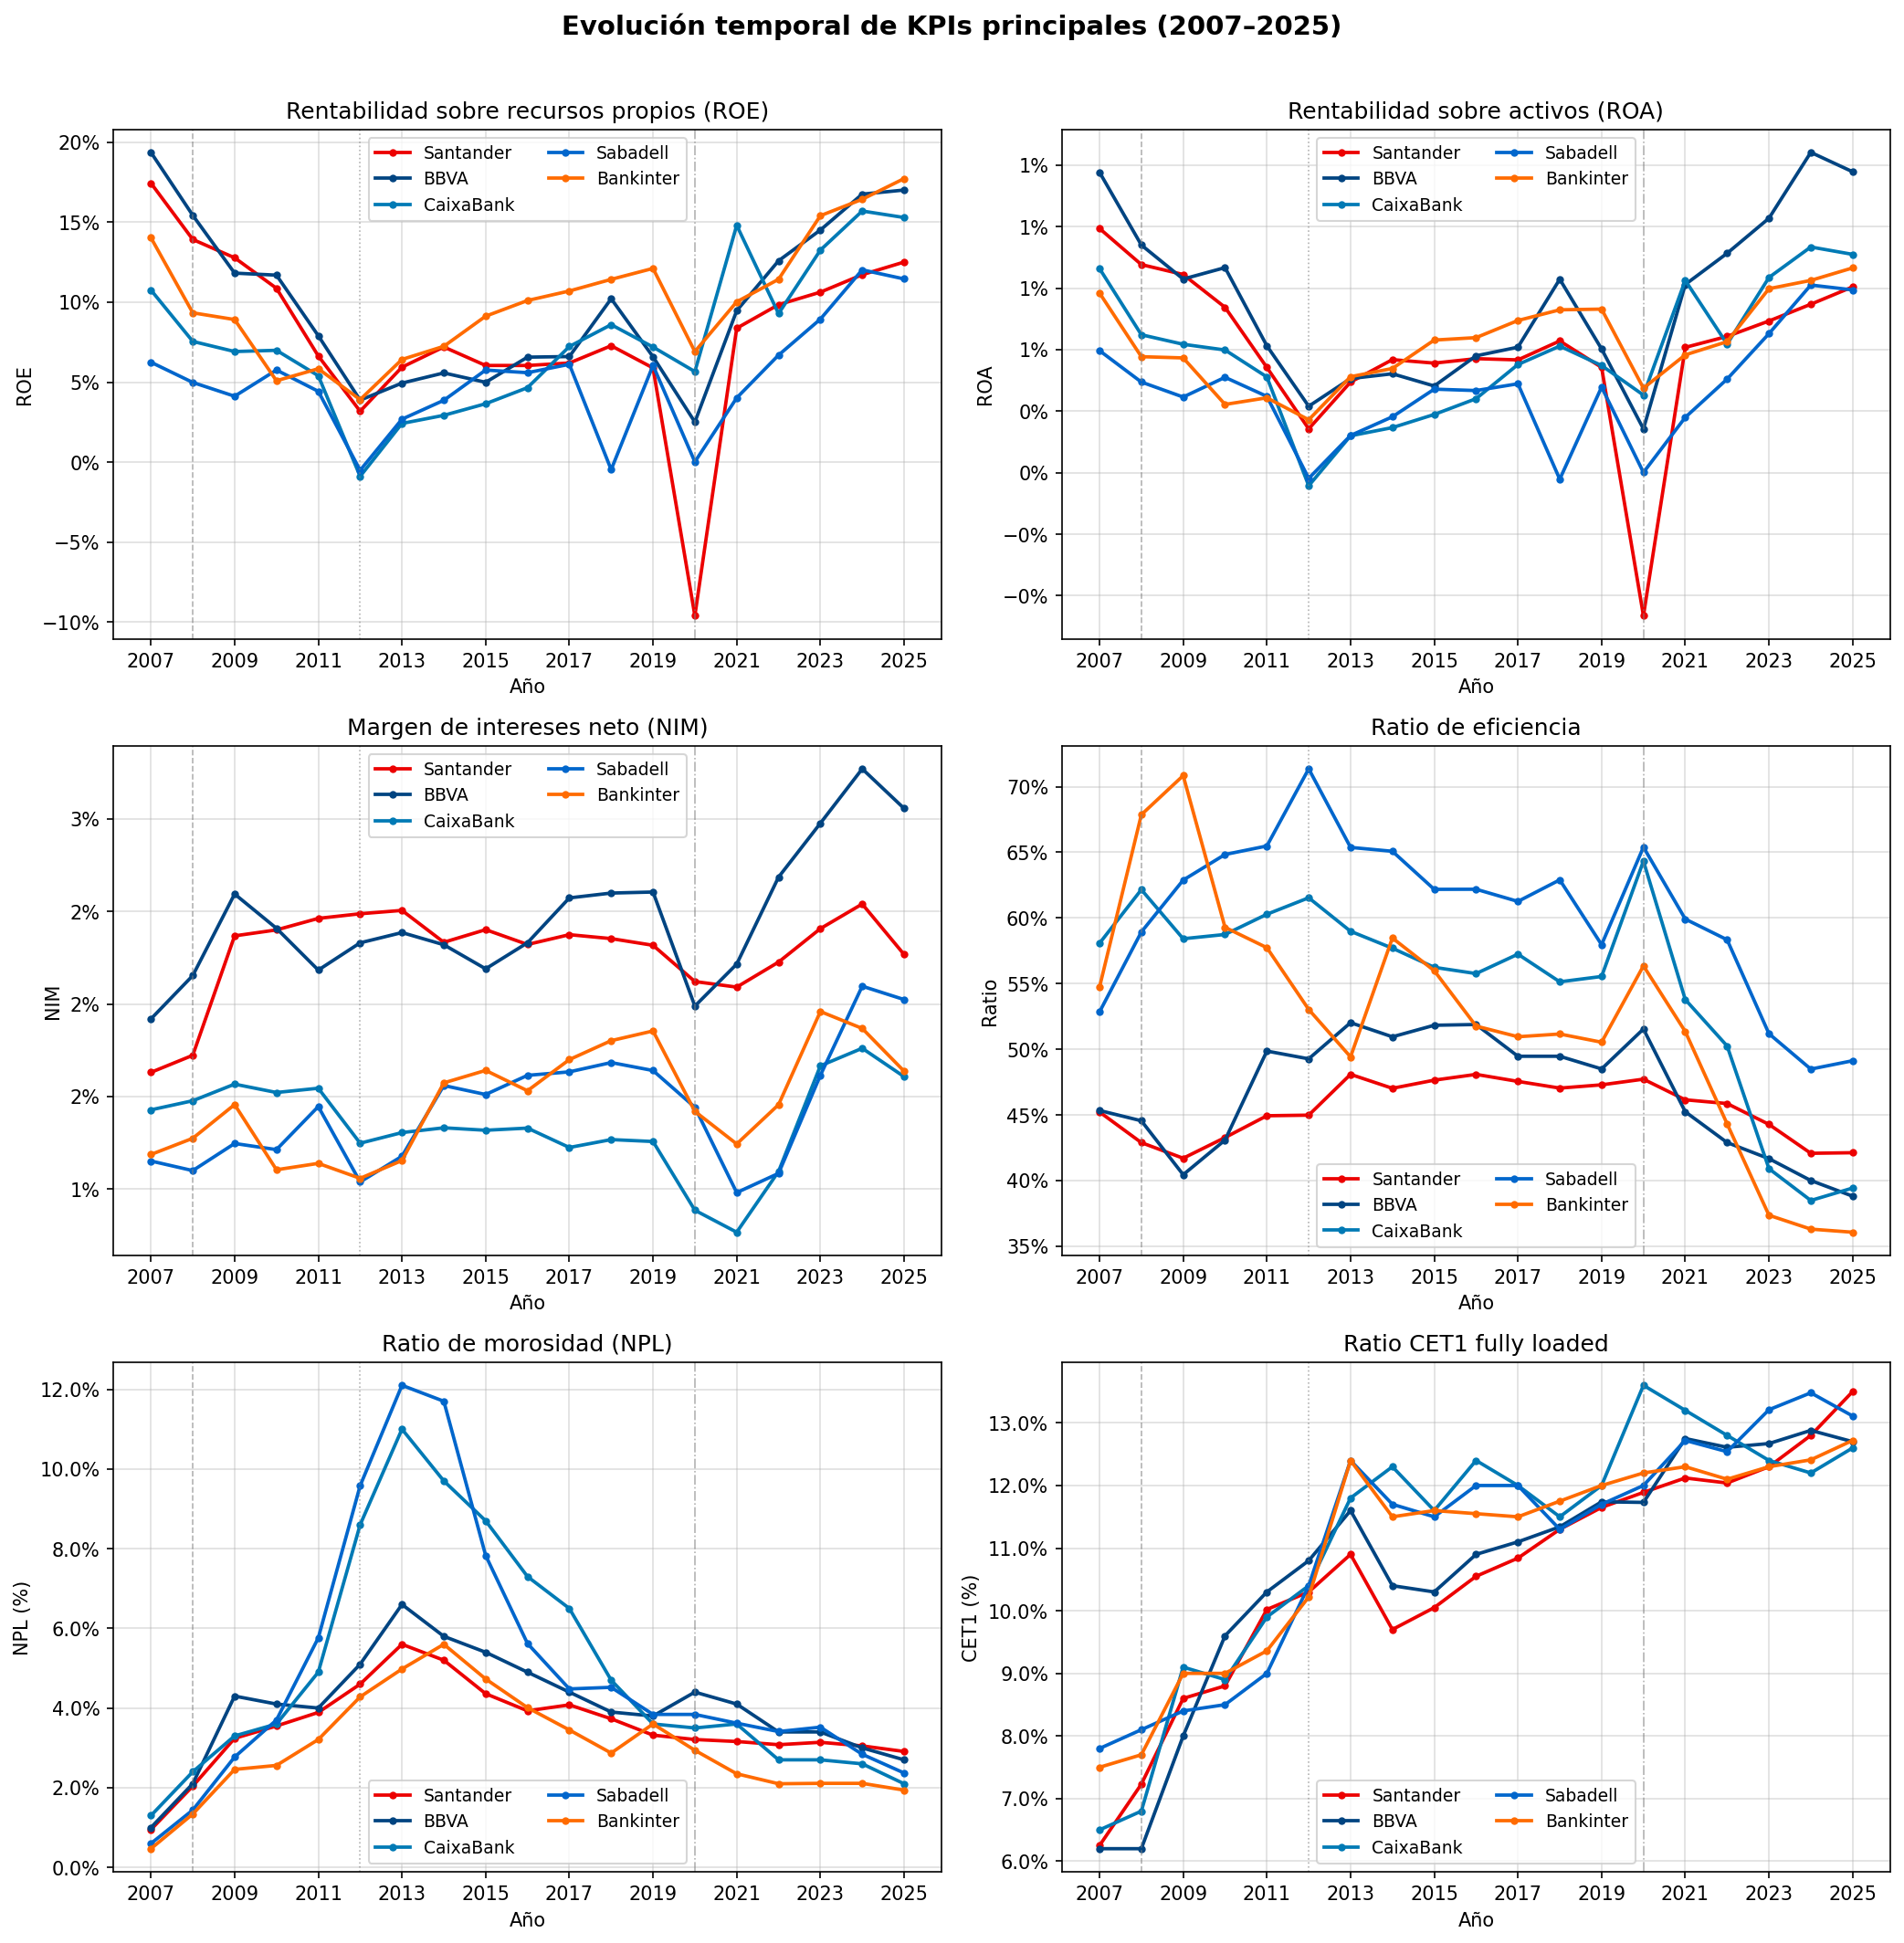

Gráfico guardado: evolucion_kpis_principales.png


In [41]:
# ── Panel completo de evolución temporal ──

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("Evolución temporal de KPIs principales (2007–2025)",
             fontsize=14, fontweight="bold", y=1.01)

plot_evolucion("ROE",             "Rentabilidad sobre recursos propios (ROE)",
               "ROE",             "pct",          axes[0, 0])
plot_evolucion("ROA",             "Rentabilidad sobre activos (ROA)",
               "ROA",             "pct",          axes[0, 1])
plot_evolucion("NIM",             "Margen de intereses neto (NIM)",
               "NIM",             "pct",          axes[1, 0])
plot_evolucion("ratio_eficiencia","Ratio de eficiencia",
               "Ratio",           "pct",          axes[1, 1])
plot_evolucion("ratio_morosidad", "Ratio de morosidad (NPL)",
               "NPL (%)",         "pct_directo",  axes[2, 0])
plot_evolucion("CET1",            "Ratio CET1 fully loaded",
               "CET1 (%)",        "pct_directo",  axes[2, 1])

plt.tight_layout()
plt.savefig("evolucion_kpis_principales.png", bbox_inches="tight")
plt.show()
print("Gráfico guardado: evolucion_kpis_principales.png")

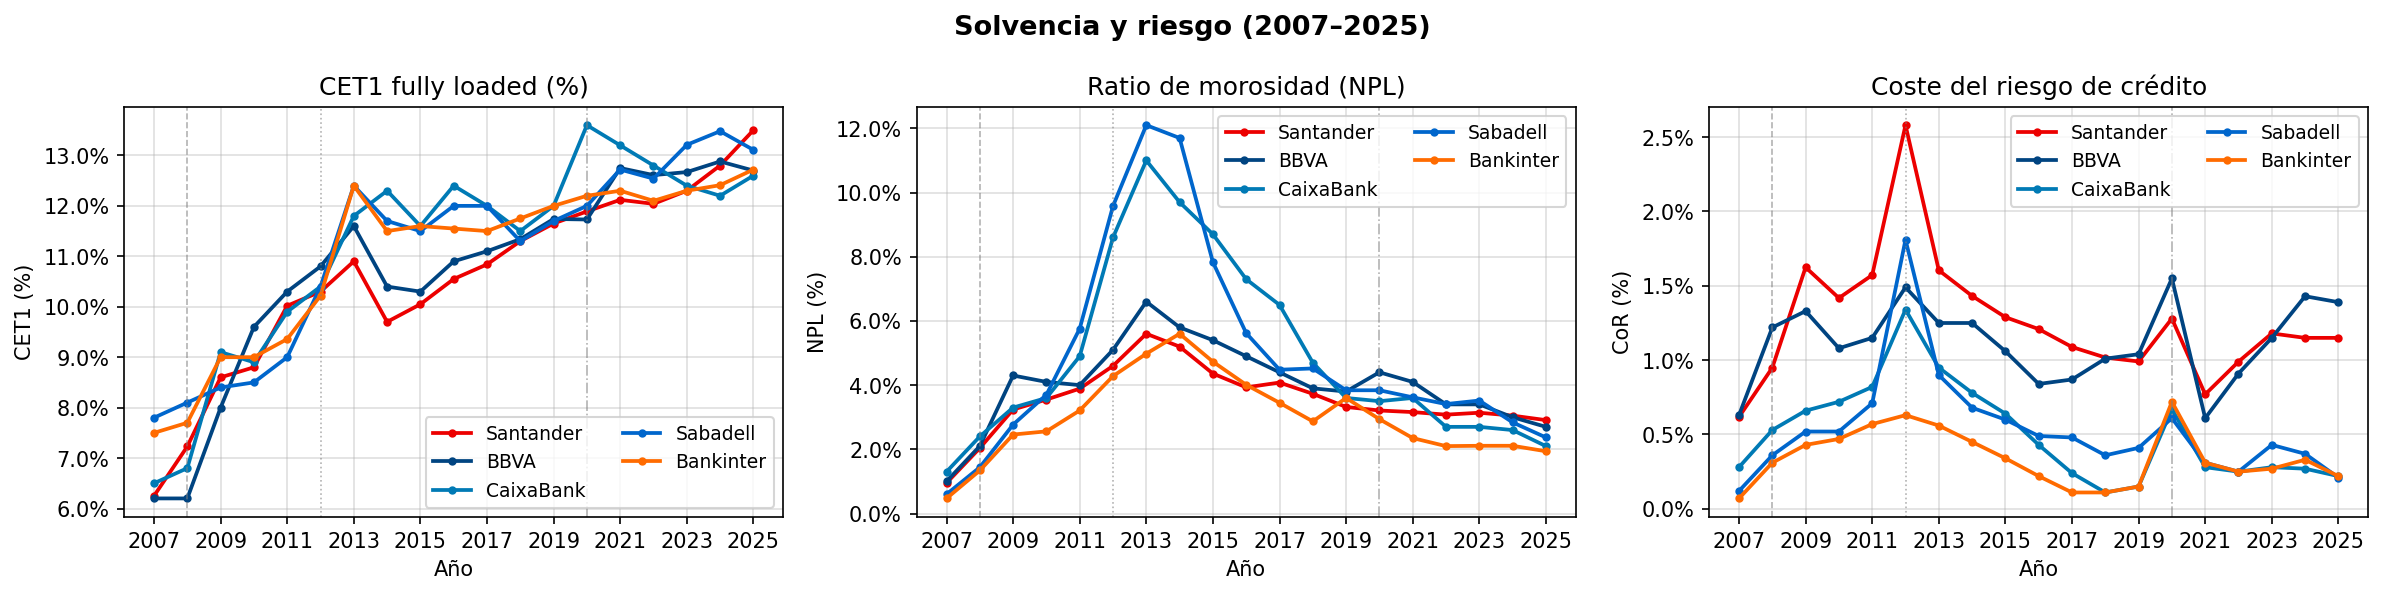

In [42]:
# ── Panel de solvencia y riesgo ──

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Solvencia y riesgo (2007–2025)",
             fontsize=13, fontweight="bold")

plot_evolucion("CET1",         "CET1 fully loaded (%)",
               "CET1 (%)",     "pct_directo", axes[0])
plot_evolucion("ratio_morosidad", "Ratio de morosidad (NPL)",
               "NPL (%)",      "pct_directo", axes[1])
plot_evolucion("coste_riesgo", "Coste del riesgo de crédito",
               "CoR (%)",      "pct_directo", axes[2])

plt.tight_layout()
plt.savefig("evolucion_solvencia_riesgo.png", bbox_inches="tight")
plt.show()

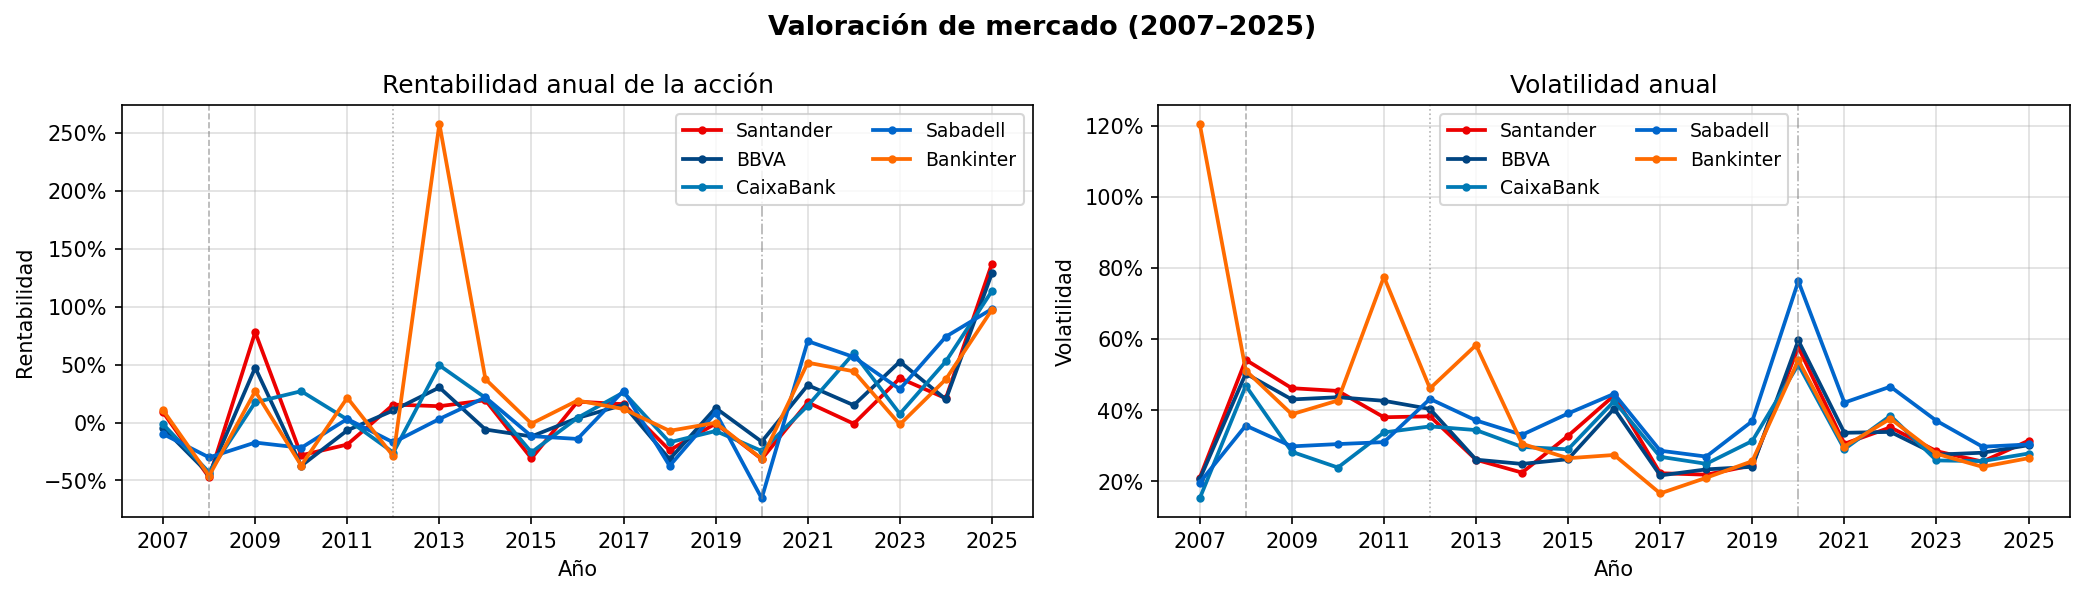

In [43]:
# ── Panel de mercado ──

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Valoración de mercado (2007–2025)",
             fontsize=13, fontweight="bold")

plot_evolucion("rentabilidad_anual_accion", "Rentabilidad anual de la acción",
               "Rentabilidad",              "pct",  axes[0])
plot_evolucion("volatilidad_anual",         "Volatilidad anual",
               "Volatilidad",               "pct",  axes[1])

plt.tight_layout()
plt.savefig("evolucion_mercado.png", bbox_inches="tight")
plt.show()

In [44]:

# COMPARATIVA ENTRE ENTIDADES

# Media histórica de cada KPI por banco (ranking)

kpis_ranking = ["ROE", "ROA", "ratio_eficiencia", "NIM",
                "CET1", "ratio_morosidad", "coste_riesgo", "LTD"]

df_ranking = df_kpis.groupby("banco")[kpis_ranking].mean().round(4)

print("=" * 60)
print("MEDIA HISTÓRICA POR BANCO (2007–2025)")
print("=" * 60)
print(df_ranking.to_string())

MEDIA HISTÓRICA POR BANCO (2007–2025)
              ROE     ROA  ratio_eficiencia     NIM     CET1  ratio_morosidad  coste_riesgo     LTD
banco                                                                                              
BBVA       0.0991  0.0070            0.4667  0.0246  10.7274           4.0211        1.1189  1.0925
Bankinter  0.1011  0.0053            0.5229  0.0148  11.0058           3.0058        0.3432  0.9909
CaixaBank  0.0776  0.0049            0.5489  0.0135  11.1579           4.8842        0.5063  0.9913
Sabadell   0.0514  0.0033            0.6030  0.0143  11.1505           4.9232        0.5337  1.0455
Santander  0.0804  0.0051            0.4547  0.0228  10.5705           3.5284        1.2587  1.1710


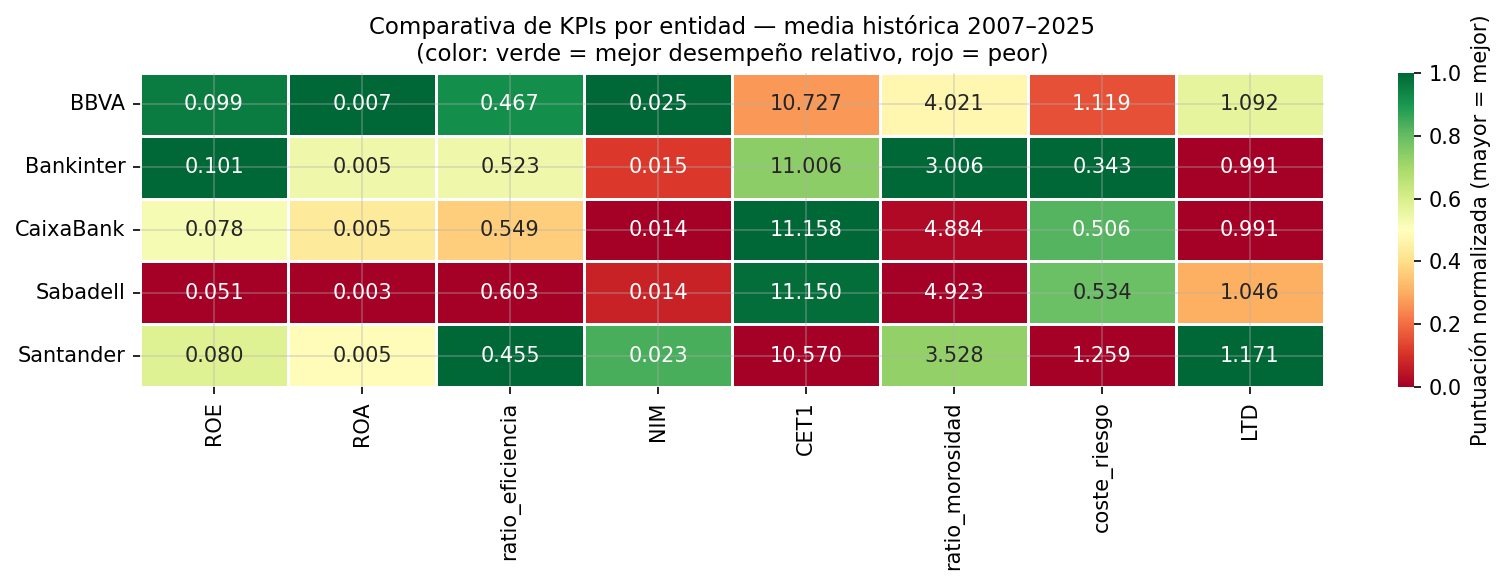

Gráfico guardado: heatmap_comparativa_bancos.png


In [45]:
# Heatmap de medias históricas normalizadas

# Normalizamos entre 0 y 1 para poder comparar KPIs en distintas escalas
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_ranking_norm = pd.DataFrame(
    scaler.fit_transform(df_ranking),
    index=df_ranking.index,
    columns=df_ranking.columns
)

# Para ratio_eficiencia, ratio_morosidad y coste_riesgo invertimos la escala
# porque valores más bajos son mejores
for col in ["ratio_eficiencia", "ratio_morosidad", "coste_riesgo"]:
    df_ranking_norm[col] = 1 - df_ranking_norm[col]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    df_ranking_norm,
    annot=df_ranking.round(3),   # muestra el valor original
    fmt=".3f",
    cmap="RdYlGn",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Puntuación normalizada (mayor = mejor)"}
)
ax.set_title("Comparativa de KPIs por entidad — media histórica 2007–2025\n"
             "(color: verde = mejor desempeño relativo, rojo = peor)",
             fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("heatmap_comparativa_bancos.png", bbox_inches="tight")
plt.show()
print("Gráfico guardado: heatmap_comparativa_bancos.png")

In [46]:
# MATRIZ DE CORRELACIÓN
# KPIs vs. variables macroeconómicas

# Unimos KPIs con variables macro
kpis_para_corr = ["ROE", "ROA", "NIM", "ratio_eficiencia",
                  "ratio_morosidad", "coste_riesgo", "CET1",
                  "rentabilidad_anual_accion", "volatilidad_anual"]

macro_vars = ["PIB_crecimiento", "inflacion", "tasa_desempleo", "tipo_interes"]

df_corr_input = df_kpis[["banco", "año"] + kpis_para_corr].merge(
    df_master[["banco", "año"] + macro_vars],
    on=["banco", "año"],
    how="left"
).dropna()

corr_matrix = df_corr_input[kpis_para_corr + macro_vars].corr().round(2)

# Submatriz: KPIs vs macro únicamente
corr_kpi_macro = corr_matrix.loc[kpis_para_corr, macro_vars]

print("=" * 60)
print("CORRELACIÓN ENTRE KPIs Y VARIABLES MACROECONÓMICAS")
print("=" * 60)
print(corr_kpi_macro.to_string())

CORRELACIÓN ENTRE KPIs Y VARIABLES MACROECONÓMICAS
                           PIB_crecimiento  inflacion  tasa_desempleo  tipo_interes
ROE                                   0.47       0.35           -0.57          0.57
ROA                                   0.46       0.31           -0.55          0.56
NIM                                   0.07      -0.04           -0.03          0.11
ratio_eficiencia                     -0.27      -0.24            0.31         -0.34
ratio_morosidad                      -0.13      -0.36            0.76         -0.46
coste_riesgo                         -0.37      -0.15            0.42         -0.11
CET1                                  0.13       0.02            0.11         -0.29
rentabilidad_anual_accion             0.23       0.13            0.10          0.03
volatilidad_anual                    -0.40       0.02           -0.00         -0.00


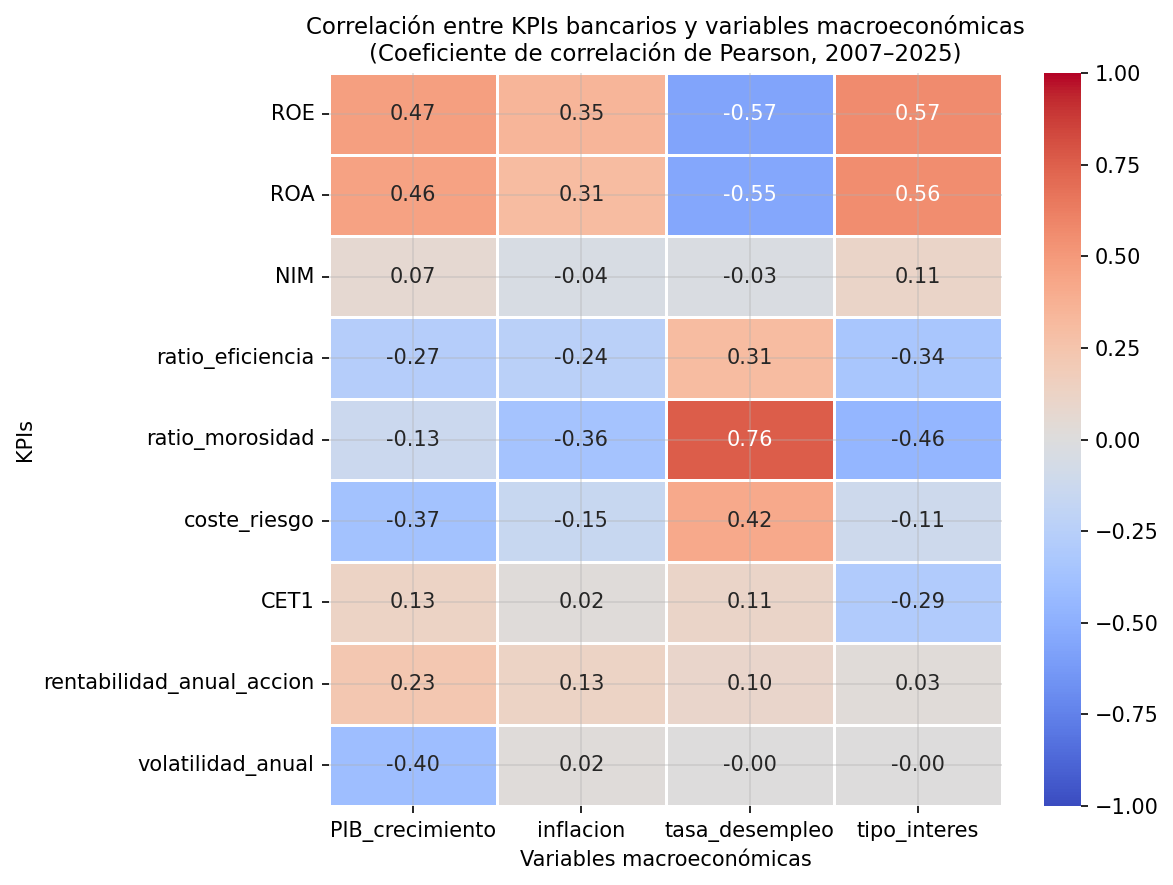

Gráfico guardado: correlacion_kpis_macro.png


In [47]:
# Heatmap de correlación KPIs vs macro

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_kpi_macro,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1
)
ax.set_title("Correlación entre KPIs bancarios y variables macroeconómicas\n"
             "(Coeficiente de correlación de Pearson, 2007–2025)",
             fontsize=11)
ax.set_xlabel("Variables macroeconómicas")
ax.set_ylabel("KPIs")
plt.tight_layout()
plt.savefig("correlacion_kpis_macro.png", bbox_inches="tight")
plt.show()
print("Gráfico guardado: correlacion_kpis_macro.png")

In [48]:
# RESUMEN DE HALLAZGOS POR PERÍODO

# Definimos los períodos del ciclo económico
periodos = {
    "Crisis financiera (2007–2009)":      (2007, 2009),
    "Crisis deuda soberana (2010–2013)":  (2010, 2013),
    "Recuperación (2014–2019)":           (2014, 2019),
    "COVID-19 (2020–2021)":               (2020, 2021),
    "Normalización tipos (2022–2025)":    (2022, 2025),
}

kpis_resumen = ["ROE", "ROA", "ratio_morosidad", "coste_riesgo", "CET1"]

print("=" * 70)
print("MEDIA DE KPIs PRINCIPALES POR PERÍODO Y BANCO")
print("=" * 70)

for periodo, (año_ini, año_fin) in periodos.items():
    print(f"\n{'─'*70}")
    print(f"  {periodo}")
    print(f"{'─'*70}")
    mask = df_kpis["año"].between(año_ini, año_fin)
    resumen = df_kpis[mask].groupby("banco")[kpis_resumen].mean().round(4)
    print(resumen.to_string())

MEDIA DE KPIs PRINCIPALES POR PERÍODO Y BANCO

──────────────────────────────────────────────────────────────────────
  Crisis financiera (2007–2009)
──────────────────────────────────────────────────────────────────────
              ROE     ROA  ratio_morosidad  coste_riesgo    CET1
banco                                                           
BBVA       0.1554  0.0098           2.4667        1.0600  6.8000
Bankinter  0.1076  0.0056           1.4233        0.2700  8.0667
CaixaBank  0.0841  0.0064           2.3333        0.4900  7.4667
Sabadell   0.0511  0.0039           1.6033        0.3333  8.1000
Santander  0.1471  0.0088           2.0767        1.0639  7.3600

──────────────────────────────────────────────────────────────────────
  Crisis deuda soberana (2010–2013)
──────────────────────────────────────────────────────────────────────
              ROE     ROA  ratio_morosidad  coste_riesgo    CET1
banco                                                           
BBVA       0.07

### 5.2 Análisis de sensibilidad macroeconómica

Se estudia la relación entre variables macroeconómicas (PIB, inflación, desempleo, tipos de interés) y el desempeño bancario mediante regresiones de panel y gráficos de dispersión.

In [49]:

#  ANÁLISIS DE SENSIBILIDAD MACROECONÓMICA
# Regresiones de panel con efectos fijos

!pip install linearmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.panel import compare
import statsmodels.api as sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.2 MB/s eta 0:00:00


In [50]:

#  PREPARACIÓN DEL DATASET DE PANEL

# Variables dependientes (KPIs)
kpis_dependientes = {
    "ROE":              "Rentabilidad sobre recursos propios",
    "ROA":              "Rentabilidad sobre activos",
    "ratio_morosidad":  "Ratio de morosidad (NPL)",
    "coste_riesgo":     "Coste del riesgo de crédito",
}

# Variables independientes (macro)
macro_vars = ["PIB_crecimiento", "inflacion", "tasa_desempleo", "tipo_interes"]

# Construimos el dataset de panel uniendo KPIs y macro
df_panel = df_kpis[["banco", "año"] + list(kpis_dependientes.keys())].merge(
    df_master[["banco", "año"] + macro_vars],
    on=["banco", "año"],
    how="left"
).dropna()

print(f"Observaciones disponibles para el panel: {len(df_panel)}")
print(f"Entidades: {df_panel['banco'].nunique()}")
print(f"Período: {df_panel['año'].min()} – {df_panel['año'].max()}")
print(f"\nObservaciones por banco:")
print(df_panel.groupby("banco").size())

Observaciones disponibles para el panel: 90
Entidades: 5
Período: 2007 – 2024

Observaciones por banco:
banco
BBVA         18
Bankinter    18
CaixaBank    18
Sabadell     18
Santander    18
dtype: int64


In [51]:
# Establecemos el índice de panel: (entidad, tiempo)
df_panel = df_panel.set_index(["banco", "año"])

print("\nEstructura del panel:")
print(df_panel.info())


Estructura del panel:
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 90 entries, ('Santander', np.int64(2024)) to ('Bankinter', np.int64(2007))
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ROE              90 non-null     float64
 1   ROA              90 non-null     float64
 2   ratio_morosidad  90 non-null     float64
 3   coste_riesgo     90 non-null     float64
 4   PIB_crecimiento  90 non-null     float64
 5   inflacion        90 non-null     float64
 6   tasa_desempleo   90 non-null     float64
 7   tipo_interes     90 non-null     float64
dtypes: float64(8)
memory usage: 6.8+ KB
None


In [52]:
# REGRESIONES DE PANEL CON EFECTOS FIJOS
# (solo efectos fijos, RE no es viable con este panel pequeño)

resultados_fe = {}

for kpi, descripcion in kpis_dependientes.items():
    print(f"\n{'='*60}")
    print(f"Variable dependiente: {descripcion} ({kpi})")
    print(f"{'='*60}")

    modelo_fe = PanelOLS(
        dependent=df_panel[kpi],
        exog=df_panel[macro_vars],
        entity_effects=True,
        time_effects=False
    )
    res_fe = modelo_fe.fit(cov_type="clustered", cluster_entity=True)
    resultados_fe[kpi] = res_fe

    print("\n── Efectos Fijos ──")
    print(res_fe.summary.tables[1])
    print(f"R² within:  {res_fe.rsquared_within:.4f}")
    print(f"R² overall: {res_fe.rsquared_overall:.4f}")
    print(f"F-stat:     {res_fe.f_statistic.stat:.4f}  "
          f"p-valor: {res_fe.f_statistic.pval:.4f}")


Variable dependiente: Rentabilidad sobre recursos propios (ROE)

── Efectos Fijos ──
                                Parameter Estimates                                
                 Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------
PIB_crecimiento     0.0042     0.0009     4.8264     0.0000      0.0025      0.0059
inflacion          -0.0015     0.0010    -1.5145     0.1338     -0.0035      0.0005
tasa_desempleo     -0.0025     0.0011    -2.2332     0.0283     -0.0048     -0.0003
tipo_interes        0.0121     0.0032     3.7590     0.0003      0.0057      0.0185
R² within:  0.6112
R² overall: -0.6617
F-stat:     31.8398  p-valor: 0.0000

Variable dependiente: Rentabilidad sobre activos (ROA)

── Efectos Fijos ──
                                Parameter Estimates                                
                 Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----

In [53]:
# JUSTIFICACIÓN DE EFECTOS FIJOS
# Test F de significancia conjunta de los efectos individuales
# H0: todos los efectos fijos son cero (OLS sería suficiente)
# H1: al menos un efecto fijo es distinto de cero (FE necesario)

print("\n" + "="*60)
print("TEST F — Significancia de los efectos fijos por entidad")
print("="*60)
print("H0: efectos individuales = 0 → OLS sería suficiente")
print("H1: efectos individuales ≠ 0 → FE es necesario")
print("-"*60)

for kpi, descripcion in kpis_dependientes.items():
    res = resultados_fe[kpi]
    # El F-test de efectos fijos está en el summary
    try:
        f_stat = res.f_statistic_robust.stat
        f_pval = res.f_statistic_robust.pval
    except:
        f_stat = res.f_statistic.stat
        f_pval = res.f_statistic.pval

    conclusion = "FE justificado (rechaza H0)" if f_pval < 0.05 \
                 else "OLS podría ser suficiente"

    print(f"\n{descripcion} ({kpi}):")
    print(f"  F-estadístico: {f_stat:.4f}  |  p-valor: {f_pval:.4f}")
    print(f"  Conclusión: {conclusion}")


TEST F — Significancia de los efectos fijos por entidad
H0: efectos individuales = 0 → OLS sería suficiente
H1: efectos individuales ≠ 0 → FE es necesario
------------------------------------------------------------

Rentabilidad sobre recursos propios (ROE):
  F-estadístico: 78.9739  |  p-valor: 0.0000
  Conclusión: FE justificado (rechaza H0)

Rentabilidad sobre activos (ROA):
  F-estadístico: 36465.7137  |  p-valor: 0.0000
  Conclusión: FE justificado (rechaza H0)

Ratio de morosidad (NPL) (ratio_morosidad):
  F-estadístico: 84.0595  |  p-valor: 0.0000
  Conclusión: FE justificado (rechaza H0)

Coste del riesgo de crédito (coste_riesgo):
  F-estadístico: 149.5415  |  p-valor: 0.0000
  Conclusión: FE justificado (rechaza H0)


In [54]:
# TABLA RESUMEN DE COEFICIENTES

print("\n" + "="*70)
print("RESUMEN DE COEFICIENTES — EFECTOS FIJOS")
print("Formato: coeficiente (p-valor) | *** p<0.01, ** p<0.05, * p<0.10")
print("="*70)

def significancia(pval):
    if pval < 0.01:  return "***"
    elif pval < 0.05: return "**"
    elif pval < 0.10: return "*"
    else:             return ""

resumen_coefs = []

for kpi in kpis_dependientes.keys():
    res = resultados_fe[kpi]
    fila = {"KPI": kpi}
    for var in macro_vars:
        coef = res.params[var]
        pval = res.pvalues[var]
        sig  = significancia(pval)
        fila[var] = f"{coef:.4f}{sig}"
    fila["R²_within"]  = f"{res.rsquared_within:.3f}"
    fila["R²_overall"] = f"{res.rsquared_overall:.3f}"
    fila["N"]          = int(res.nobs)
    resumen_coefs.append(fila)

df_resumen = pd.DataFrame(resumen_coefs).set_index("KPI")
print(df_resumen.to_string())


RESUMEN DE COEFICIENTES — EFECTOS FIJOS
Formato: coeficiente (p-valor) | *** p<0.01, ** p<0.05, * p<0.10
                PIB_crecimiento  inflacion tasa_desempleo tipo_interes R²_within R²_overall   N
KPI                                                                                            
ROE                   0.0042***    -0.0015      -0.0025**    0.0121***     0.611     -0.662  90
ROA                   0.0003***  -0.0002**      -0.0002**    0.0008***     0.608     -0.665  90
ratio_morosidad       0.0710***  -0.0819**      0.3412***       0.0053     0.679      0.793  90
coste_riesgo         -0.0389***  0.0351***      0.0484***    0.0641***     0.667      0.773  90


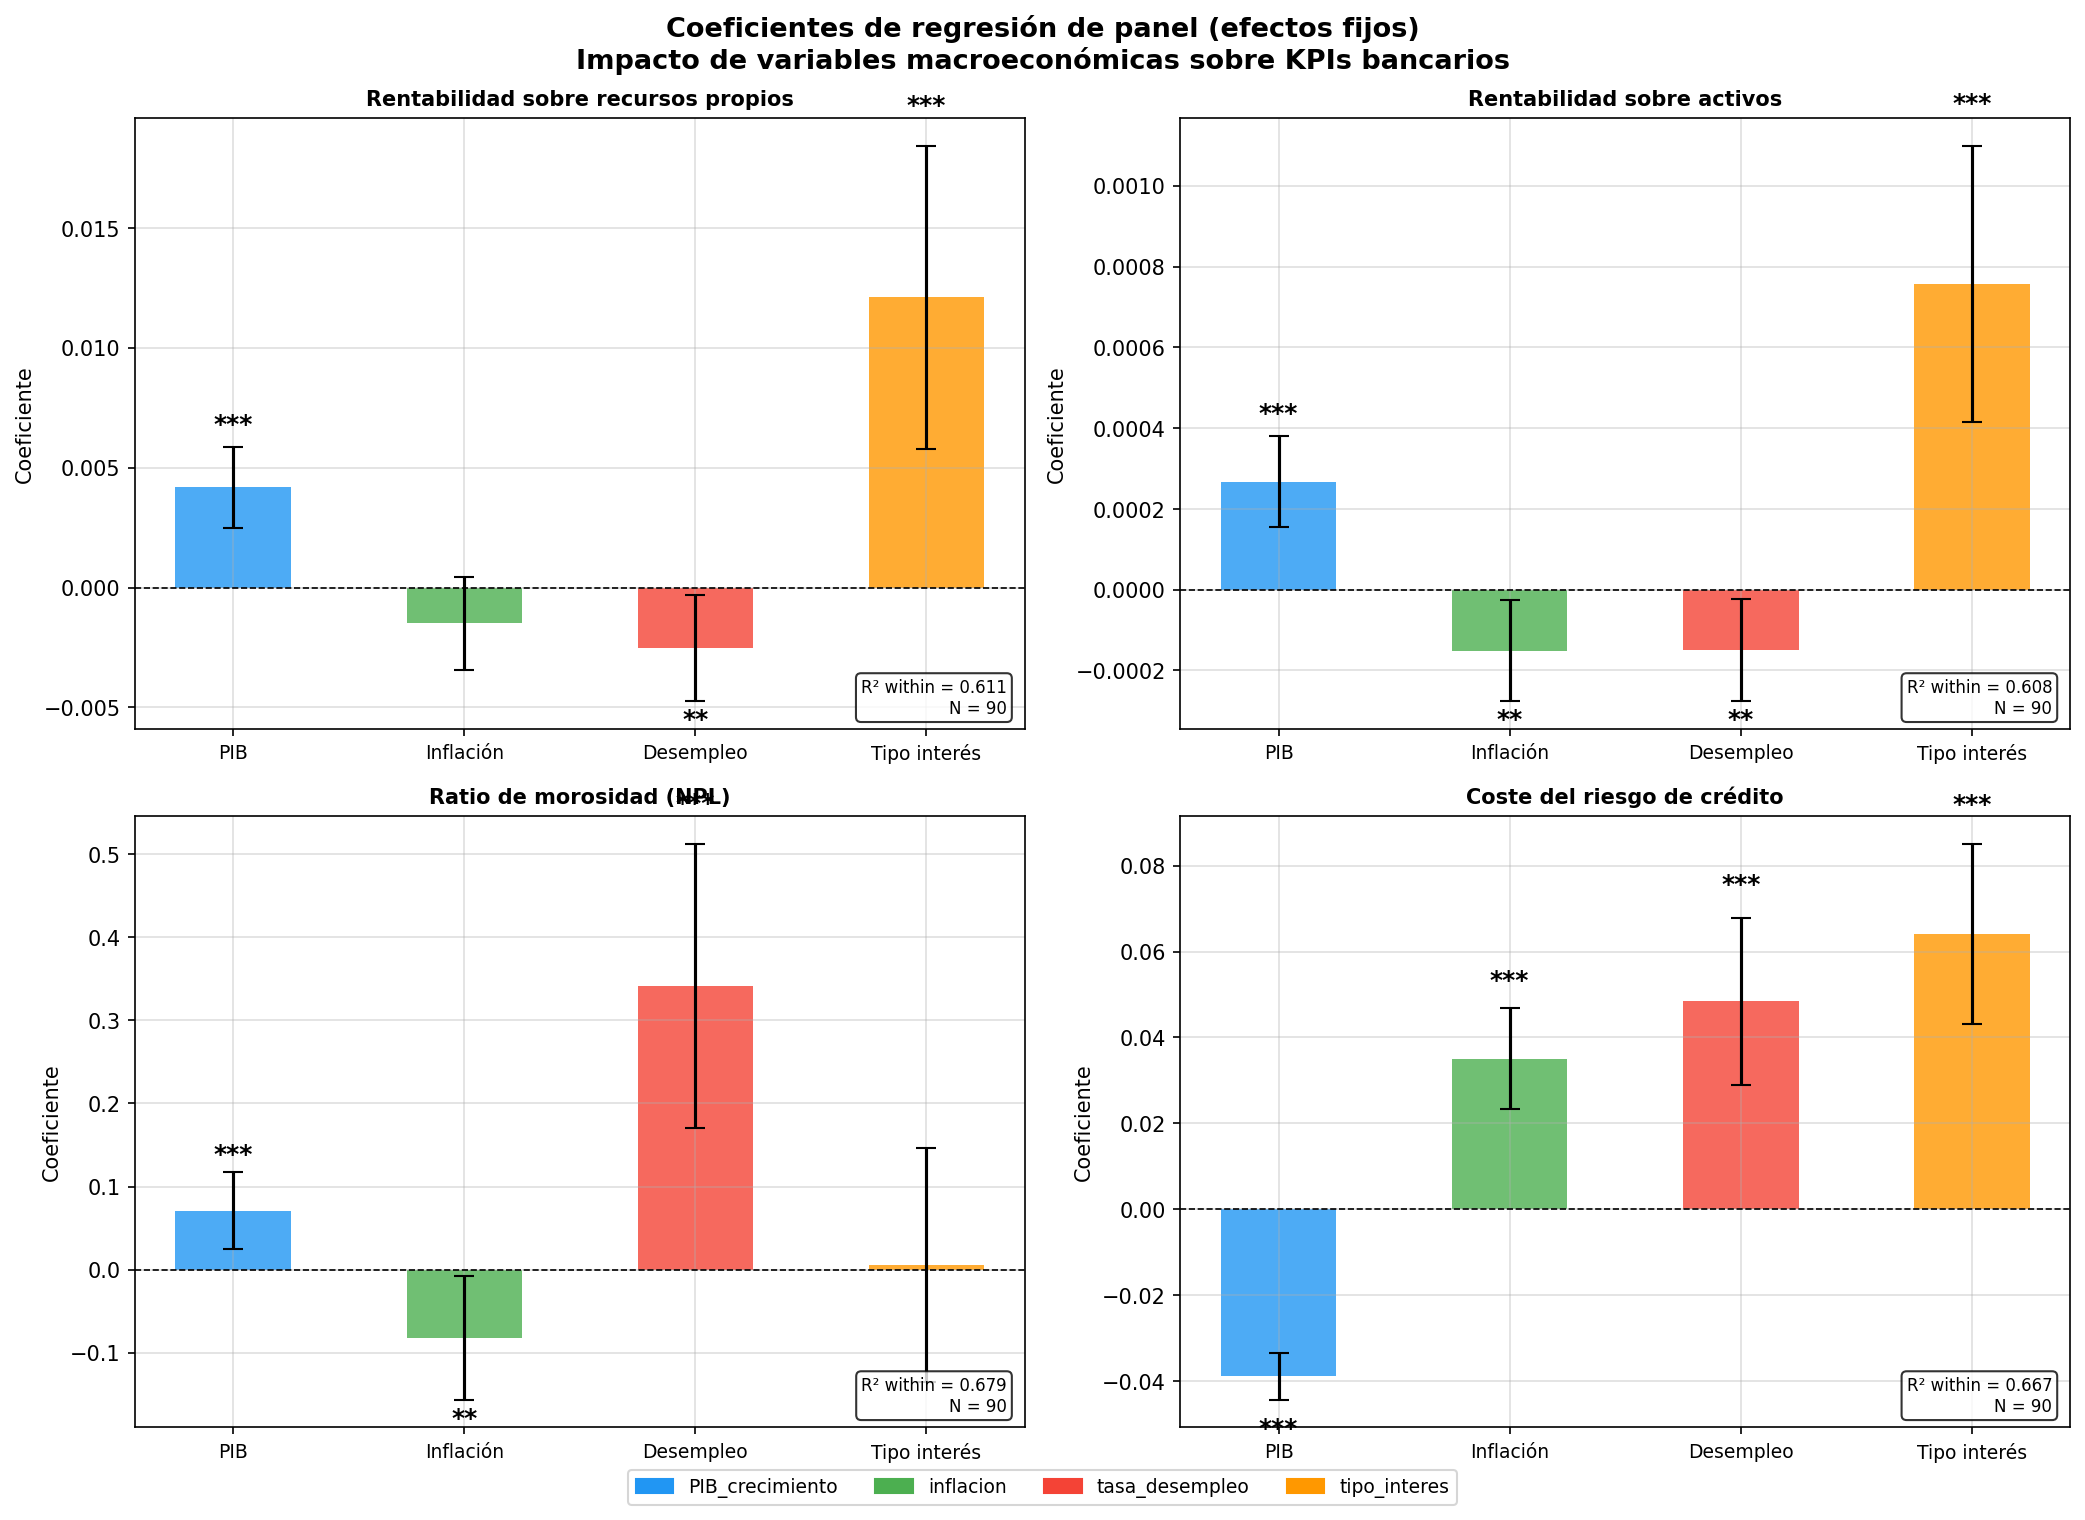

Gráfico guardado: coeficientes_panel_macro.png


In [55]:
# VISUALIZACIÓN DE COEFICIENTES
# Gráfico de coeficientes con intervalos de confianza al 95%

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Coeficientes de regresión de panel (efectos fijos)\n"
             "Impacto de variables macroeconómicas sobre KPIs bancarios",
             fontsize=13, fontweight="bold")

axes_flat = axes.flatten()
colores_vars = {
    "PIB_crecimiento": "#2196F3",
    "inflacion":       "#4CAF50",
    "tasa_desempleo":  "#F44336",
    "tipo_interes":    "#FF9800"
}

for idx, (kpi, descripcion) in enumerate(kpis_dependientes.items()):
    ax = axes_flat[idx]
    res = resultados_fe[kpi]

    coefs  = res.params[macro_vars].values
    errors = res.std_errors[macro_vars].values * 1.96  # IC 95%
    pvals  = res.pvalues[macro_vars].values

    x_pos = np.arange(len(macro_vars))
    colores = [colores_vars[v] for v in macro_vars]

    bars = ax.bar(x_pos, coefs, color=colores, alpha=0.8, width=0.5)
    ax.errorbar(x_pos, coefs, yerr=errors, fmt="none",
                color="black", capsize=5, linewidth=1.5)

    # Añadir asteriscos de significancia
    for i, (coef, pval) in enumerate(zip(coefs, pvals)):
        sig = significancia(pval)
        if sig:
            offset = max(abs(coef), errors[i]) * 0.1
            y_pos  = coef + errors[i] + offset if coef >= 0 else coef - errors[i] - offset
            ax.text(i, y_pos, sig, ha="center", va="bottom" if coef >= 0 else "top",
                    fontsize=12, fontweight="bold")

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(descripcion, fontsize=10, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(["PIB", "Inflación", "Desempleo", "Tipo interés"],
                       fontsize=9)
    ax.set_ylabel("Coeficiente")

    # Leyenda de R²
    ax.text(0.98, 0.02,
            f"R² within = {res.rsquared_within:.3f}\nN = {int(res.nobs)}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Leyenda global
parches = [mpatches.Patch(color=c, label=v)
           for v, c in colores_vars.items()]
fig.legend(handles=parches, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)

plt.tight_layout()
plt.savefig("coeficientes_panel_macro.png", bbox_inches="tight")
plt.show()
print("Gráfico guardado: coeficientes_panel_macro.png")


MEDIA DE KPIs POR RÉGIMEN DE TIPOS DE INTERÉS
                          ROE     ROA  ratio_morosidad  coste_riesgo
regimen_tipos                                                       
Tipos negativos (<0%)  0.0633  0.0040           4.7572        0.6739
Tipos bajos (0–1%)     0.0656  0.0041           4.7490        0.9787
Tipos medios (1–3%)    0.1418  0.0087           1.6340        0.4908
Tipos altos (>3%)      0.1244  0.0076           2.5193        0.6819


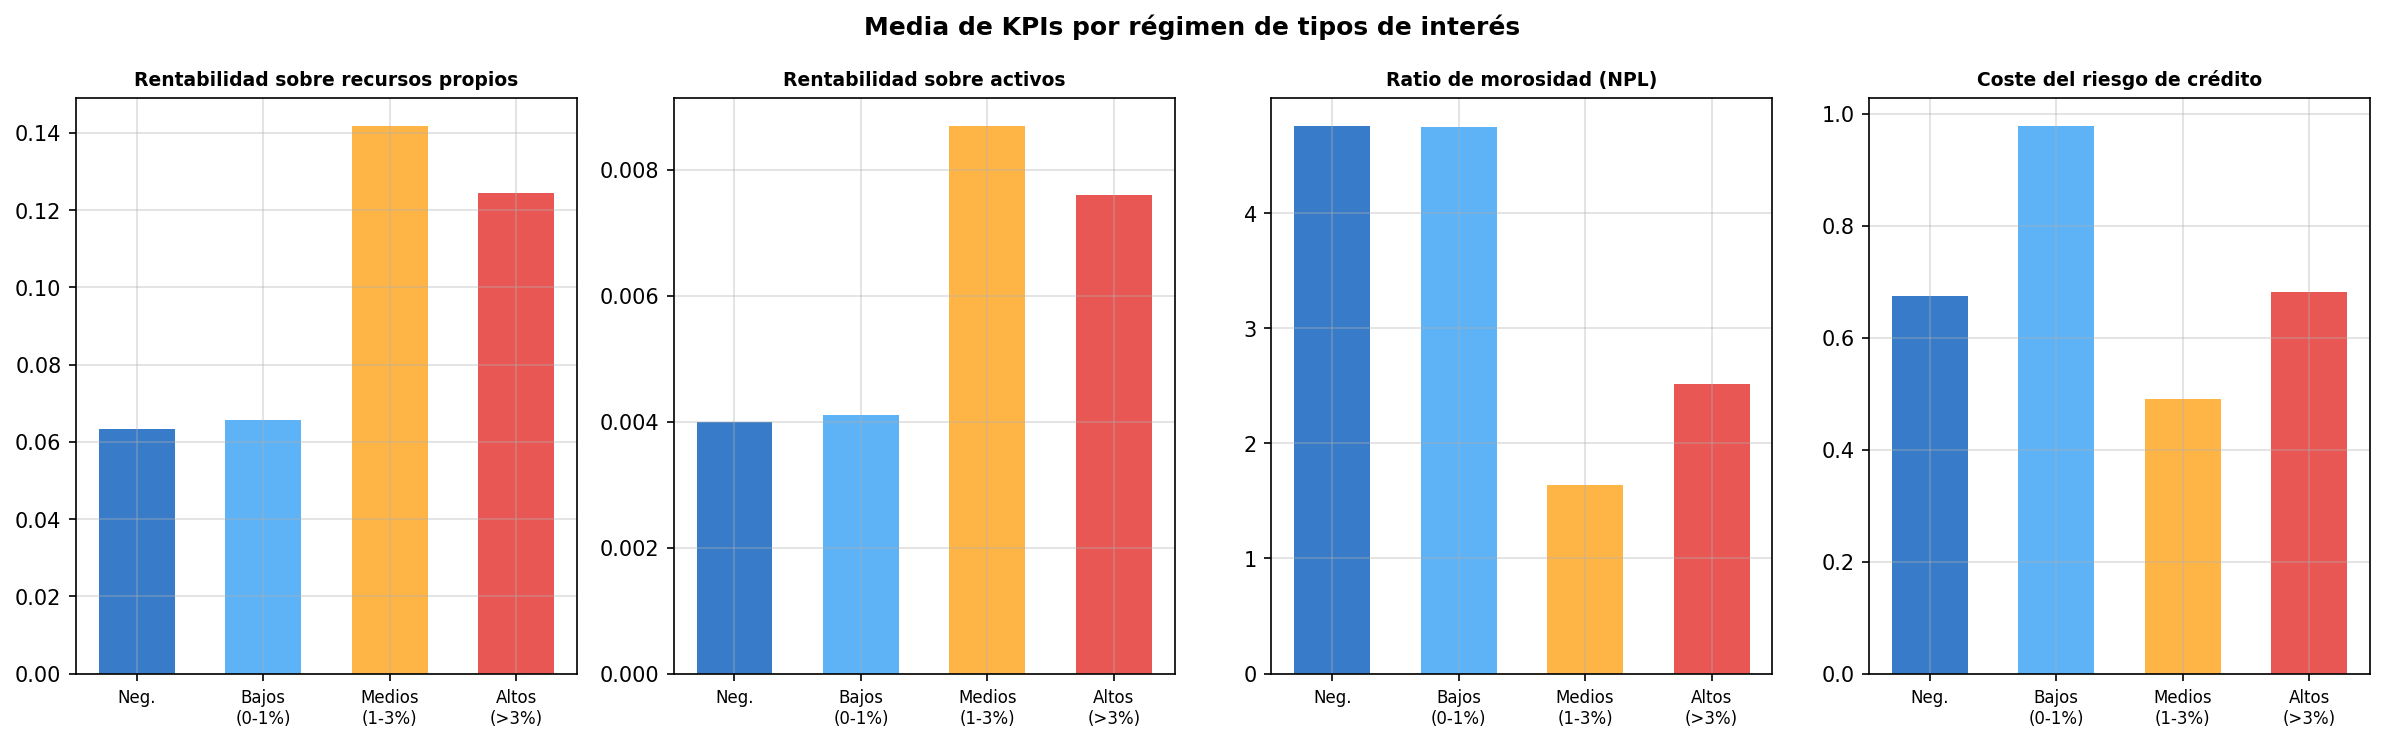

Gráfico guardado: kpis_por_regimen_tipos.png


In [56]:
# ANÁLISIS POR ESCENARIOS MACRO
# Valores medios de KPIs en diferentes regímenes de tipos

# Clasificamos cada año en régimen de tipos
def clasificar_tipo(t):
    if t < 0:    return "Tipos negativos (<0%)"
    elif t < 1:  return "Tipos bajos (0–1%)"
    elif t < 3:  return "Tipos medios (1–3%)"
    else:        return "Tipos altos (>3%)"

df_escenarios = df_kpis[["banco", "año"] + list(kpis_dependientes.keys())].merge(
    df_master[["banco", "año", "tipo_interes", "tasa_desempleo"]],
    on=["banco", "año"], how="left"
).dropna()

df_escenarios["regimen_tipos"] = df_escenarios["tipo_interes"].apply(clasificar_tipo)

orden_regimen = [
    "Tipos negativos (<0%)",
    "Tipos bajos (0–1%)",
    "Tipos medios (1–3%)",
    "Tipos altos (>3%)"
]

print("\n" + "="*70)
print("MEDIA DE KPIs POR RÉGIMEN DE TIPOS DE INTERÉS")
print("="*70)

resumen_regimen = df_escenarios.groupby("regimen_tipos")[
    list(kpis_dependientes.keys())
].mean().reindex(orden_regimen).round(4)

print(resumen_regimen.to_string())

# Gráfico
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Media de KPIs por régimen de tipos de interés",
             fontsize=12, fontweight="bold")

colores_regimen = ["#1565C0", "#42A5F5", "#FFA726", "#E53935"]

for idx, (kpi, descripcion) in enumerate(kpis_dependientes.items()):
    ax = axes[idx]
    valores = resumen_regimen[kpi].values
    ax.bar(range(len(orden_regimen)), valores,
           color=colores_regimen, alpha=0.85, width=0.6)
    ax.set_title(descripcion, fontsize=9, fontweight="bold")
    ax.set_xticks(range(len(orden_regimen)))
    ax.set_xticklabels(["Neg.", "Bajos\n(0-1%)", "Medios\n(1-3%)", "Altos\n(>3%)"],
                       fontsize=8)
    ax.axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig("kpis_por_regimen_tipos.png", bbox_inches="tight")
plt.show()
print("Gráfico guardado: kpis_por_regimen_tipos.png")